In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time, os, sys

sys.path.append(os.path.abspath("./src"))

from sparse_methods import matricies
from sampling import samp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]

## Sampling 

Take the distribution:

$$p(x) = \frac{1}{Z}e^{-V(x)} $$

Where

$$V(x) = \frac{x^{2}}{10} + \sin(x) + e^{-5x^{2}}, \qquad Z = \int_{-\infty}^{\infty}e^{-V(x)}dx$$

This is the Boltzmann form, which turns any energy function you can evaluate into a density: where $V(x)$ is our energy, low $V$ means high probability, and $Z$ is whatever constant makes the thing integrate to 1. The quadratic keeps the tails from running away and is what makes $Z$ finite at all.

Since $e^{-x}$ is decreasing, the mode of $p$ sits wherever $V$ is smallest (this is easy to see mathematically, but is also the definition of energy in this instance), so finding the most probable point is thus a minimization problem and not a sampling problem. Both get done below, along with a second sampler that goes through the CDF instead.

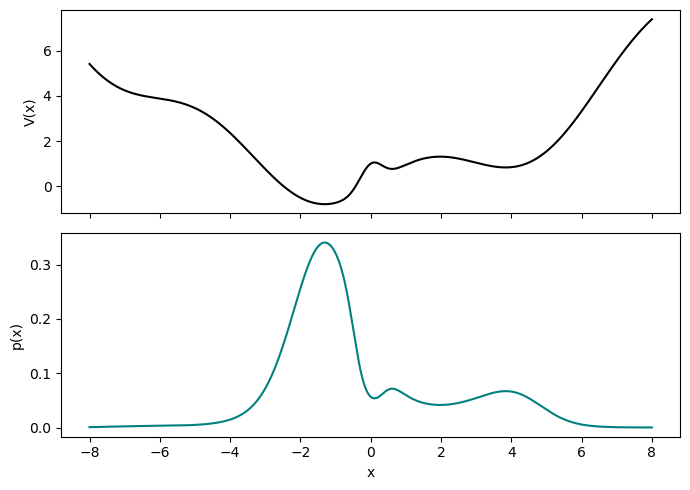

Z = 6.497698


In [3]:
v = lambda x: (
    (x**2 / 10) + (np.sin(x)) + (np.exp(-5*(x**2)))
)

z = integrals.midpoint_area(lambda x: np.exp(-v(x)), -10, 10, 20_000)

p = lambda x: (
    (1 / z) * (np.exp(-v(x)))
)

xs = np.linspace(-8, 8, 2_000)

fig, (top, bottom) = plt.subplots(2, 1, figsize = (7, 5), sharex = True)

top.plot(xs, v(xs), color = "black")
top.set_ylabel("V(x)")

bottom.plot(xs, p(xs), color = "teal")
bottom.set_ylabel("p(x)")
bottom.set_xlabel("x")

plt.tight_layout()
plt.show()

print(f"Z = {z:.6f}")

### Metropolis MCMC

The naive approach to sample from some probability is to use an inverse cdf: sample from $u \sim U(0, 1)$, then find $x$ such that $\text{cdf}(x) = u$. The issue with this is not only that solving for $x$ almost always requires using a root-finding algorithm, but the cdf itself is almost always the integral of a non-trival function. This means that for each sample, we need to take the integral of a function using midpoint or some other algorithm. This can get expensive quickly.

Sampling from $p$ uses the same proposal and the same accept step, minus the temperature:

$$\alpha = \min\left(1,\; e^{-\left(V(x') - V(x^{(k)})\right)}\right) = \min\left(1,\; \frac{p(x')}{p(x^{(k)})}\right)$$

Written the second way it is clear what is going on, and also clear why this method is the one everybody uses. The acceptance probability depends on $p$ only through a ratio, so $Z$ cancels out of it. You can sample from a distribution you cannot normalize, which matters enormously in higher dimensions where $Z$ is an integral nobody can do.

The chain that results satisfies detailed balance with respect to $p$, meaning $p$ is its stationary distribution, so after enough steps the states it visits are distributed like $p$ and a histogram of them approximates the density. What you give up is independence: consecutive samples differ by at most one proposal, so they are heavily correlated, and 1000 MCMC samples carry much less information than 1000 independent ones.

The chain starts at $x = 0$, which is not a typical draw from $p$, so the first samples are pulled toward the start. Discarding the first 20 is enough here given how narrow the distribution is and that the proposal moves on the same scale.

`mcmc_sample` also takes a thinning factor, which keeps only every $j$th state and throws the rest away. It cuts the correlation between stored samples at $j$ times the runtime. The required run below uses no thinning.

1000 samples in 22.41 ms
sample mean -0.2489, sample std 2.1831


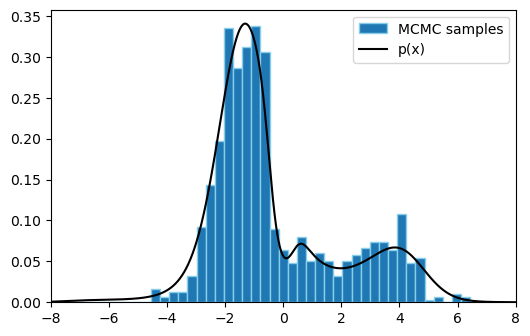

In [4]:
start = time.perf_counter_ns()

samples = samp.mcmc_sample(v, n = 10**3)

mcmc_time = (time.perf_counter_ns() - start) * 1e-6

print(f"1000 samples in {mcmc_time:.2f} ms")
print(f"sample mean {samples.mean():.4f}, sample std {samples.std():.4f}")

plt.hist(samples, bins = 51, density = True, edgecolor = "skyblue", range = (-8, 8), label = "MCMC samples")
plt.plot(xs, p(xs), color = "black", label = "p(x)")
plt.xlim(-8, 8)
plt.legend()
plt.show()

One deliberate deviation from the assignment text, which says to store a sample only when a proposal is accepted. The implementation stores the state of the chain at every step after burn-in instead.

A rejection still counts as a step. The chain stays where it is for another turn, and it stays put most often where it is already sitting on high probability, since that is where proposals are most likely to be worse. Dropping rejected steps therefore throws away time the chain spends in exactly the places that should be weighted most heavily. Every-state storage is also the standard Metropolis estimator, and the one detailed balance is proved for.

The effect is small, but it leans the same way every time. Below, 20,000 samples each way against the exact probabilities from the integrator:

In [5]:
rand = np.random.default_rng()

# Here only to test the storage rule against mcmc_sample. Not the submitted sampler.
def accepted_only(n: int) -> np.ndarray:
    x_k = 0.0
    kept = []

    while len(kept) < n + 20:
        proposed = x_k + rand.normal()

        if rand.random() < np.exp(v(x_k) - v(proposed)):
            x_k = proposed
            kept.append(x_k)

    return np.array(kept[20:])

accepted = accepted_only(20_000)
every_state = samp.mcmc_sample(v, n = 20_000)

print(f"{'interval':>16} {'accepted only':>15} {'every state':>13} {'exact':>9}")

for lower, upper in ((-3, -0.5), (-0.5, 0.5), (2, 5)):
    print(f"  P({lower:>4}, {upper:>4}) {np.mean((accepted > lower) & (accepted < upper)):>19.3f}"
          f" {np.mean((every_state > lower) & (every_state < upper)):>13.3f}"
          f" {integrals.midpoint_area(p, lower, upper, 20_000):>9.3f}")

        interval   accepted only   every state     exact
  P(  -3, -0.5)               0.571         0.589     0.605
  P(-0.5,  0.5)               0.087         0.083     0.081
  P(   2,    5)               0.181         0.169     0.162


Accepted-only sampling pulls several points of mass out of the deepest well and spreads it over the flatter ground on either side, run after run. Every-state storage tracks the exact numbers much more closely, and what wobble is left there comes from how correlated the chain is rather than from the storage rule. The bias is not large enough to wreck the histogram, but it is bias and not variance, so throwing more samples at it will not help.

### Inverse CDF sampling

The third approach needs no chain at all. If $F$ is the CDF of $p$ and $u \sim U(0, 1)$, then $F^{-1}(u) \sim p$, because $F$ maps the distribution onto a uniform by construction. So sample a uniform, solve $F(x) = u$ for $x$, and the result is an independent draw from $p$.

Doing it here means stacking three pieces from earlier in the course:

$Z$ comes from the midpoint approximation of Assignment 1 over 20,000 points, with the infinite bounds replaced by $\pm 10$. That truncation is harmless: $e^{-V}$ at the endpoints is about three parts in one hundred thousand of its value at the mode, and the tails beyond contribute far less than the tolerances used anywhere else here.

$F(x) = \int_{-10}^{x}p(t)\,dt$ comes from the same integrator over 10,000 points.

$F(x) = u$ gets solved by the bisection routine from Assignment 1. It brackets the root by sampling a scale that doubles until it finds a sign change, then halves the interval until $|F(x) - u| < 10^{-3}$. The routine was rewritten between assignments, iteratively rather than recursively and carrying the bracket's function values along, so each step costs one evaluation of $F$ rather than the five or six the original spent re-evaluating what it already knew.

Stacking them is expensive. One evaluation of $F$ costs 10,000 evaluations of $p$, one root solve averages eight halvings plus a few more evaluations finding the bracket, and one sample costs one root solve. That is on the order of $10^{5}$ evaluations of $V$ per sample, against roughly one per MCMC step. The runtime comparison at the end is decided right here.

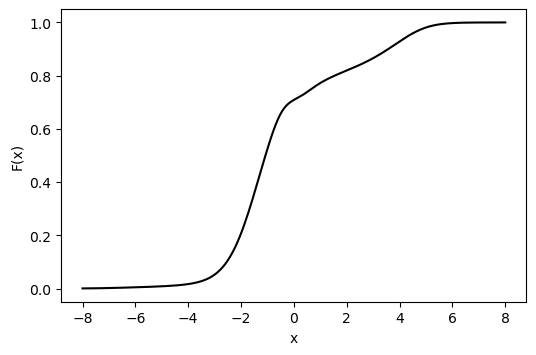

F(x) = 0.1  ->  x =  -2.5383,  check: F(x) = 0.1005
F(x) = 0.5  ->  x =  -1.0769,  check: F(x) = 0.5002
F(x) = 0.9  ->  x =   3.5685,  check: F(x) = 0.8997


In [6]:
cdf_x = np.linspace(-8, 8, 200)
cdf_y = np.array([samp.cdf(t, p) for t in cdf_x])

plt.plot(cdf_x, cdf_y, color = "black")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.show()

for u in (0.1, 0.5, 0.9):
    root = samp.inverse_cdf(u, distribution = p)
    print(f"F(x) = {u}  ->  x = {root:>8.4f},  check: F(x) = {samp.cdf(root, p):.4f}")

1000 samples in 15074.16 ms
sample mean -0.4797, sample std 2.2352


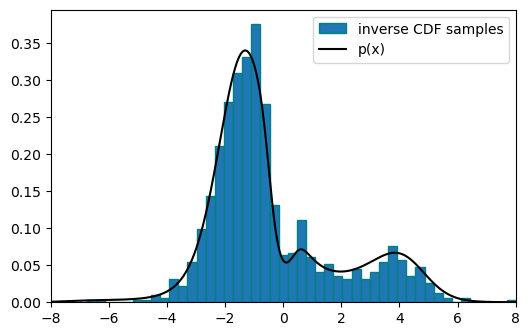

In [7]:
start = time.perf_counter_ns()

cdf_samples = samp.cdf_sampling(distribution = p, n = 10**3)

cdf_time = (time.perf_counter_ns() - start) * 1e-6

print(f"1000 samples in {cdf_time:.2f} ms")
print(f"sample mean {cdf_samples.mean():.4f}, sample std {cdf_samples.std():.4f}")

plt.hist(cdf_samples, bins = 51, density = True, edgecolor = "teal", range = (-8, 8), label = "inverse CDF samples")
plt.plot(xs, p(xs), color = "black", label = "p(x)")
plt.xlim(-8, 8)
plt.legend()
plt.show()

### Comparing the two samplers

Both histograms sit on $p$, so the comparison is about what each one costs and what its samples are worth.

In [8]:
true_mean = integrals.midpoint_area(lambda t: t * p(t), -10, 10, 20_000)

def lag_one(s: np.ndarray) -> float:
    centered = s - s.mean()
    return float((centered[:-1] * centered[1:]).sum() / (centered * centered).sum())

# Effective sample size under the usual AR(1) approximation, n(1 - r) / (1 + r).
# It can come out slightly above n when the measured correlation is negative.
effective = lambda s: len(s) * (1 - lag_one(s)) / (1 + lag_one(s))

print(f"{'':>14} {'runtime (ms)':>14} {'sample mean':>13} {'lag-1 autocorr':>16} {'effective n':>13}")
print(f"{'MCMC':>14} {mcmc_time:>14.2f} {samples.mean():>13.4f} {lag_one(samples):>16.3f} {effective(samples):>13.0f}")
print(f"{'inverse CDF':>14} {cdf_time:>14.2f} {cdf_samples.mean():>13.4f} {lag_one(cdf_samples):>16.3f} {effective(cdf_samples):>13.0f}")
print(f"{'exact':>14} {'':>14} {true_mean:>13.4f}")
print(f"\ninverse CDF is {cdf_time / mcmc_time:.0f}x slower for the same 1000 samples")

                 runtime (ms)   sample mean   lag-1 autocorr   effective n
          MCMC          22.41       -0.2489            0.945            29
   inverse CDF       15074.16       -0.4797           -0.008          1015
         exact                      -0.3903

inverse CDF is 673x slower for the same 1000 samples


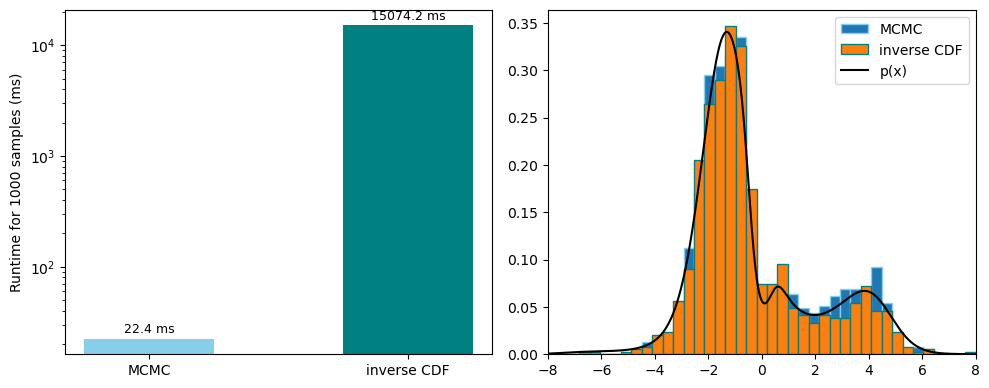

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize = (10, 4))

left.bar(["MCMC", "inverse CDF"], [mcmc_time, cdf_time], color = ["skyblue", "teal"], width = 0.5)
left.set_yscale("log")
left.set_ylabel("Runtime for 1000 samples (ms)")
left.bar_label(left.containers[0], fmt = "%.1f ms", padding = 2, fontsize = 9)

right.hist(samples, bins = 41, density = True, range = (-8, 8), edgecolor = "skyblue", label = "MCMC")
right.hist(cdf_samples, bins = 41, density = True, range = (-8, 8), edgecolor = "teal", label = "inverse CDF")
right.plot(xs, p(xs), color = "black", label = "p(x)")
right.set_xlim(-8, 8)
right.legend()

plt.tight_layout()
plt.show()

The runtime gap runs to two or three orders of magnitude, and it is not a surprise given the cost stack in the last section. MCMC does one evaluation of $V$ per proposal. Inverse CDF does a full quadrature grid per evaluation of $F$, twenty or so evaluations of $F$ per root solve, and one root solve per sample. Tuning the constants on either side would not change which one wins.

What MCMC pays for that speed is in the last two columns. Its lag-1 autocorrelation runs around $0.94$, meaning consecutive samples are almost the same information, and the usual $n(1 - r)/(1 + r)$ estimate puts the effective size of those 1000 samples at about thirty independent draws. That is the reason its sample mean wanders by a few tenths from run to run against a true mean near $-0.39$, which for 1000 genuine samples of a distribution this narrow would be far too much. The inverse CDF samples are independent by construction, their autocorrelation sits at zero up to noise, all 1000 of them count, and the mean lands closer and stays there.

There are obvious ways to shrink the gap on the slow side. Nothing forces $F$ to be recomputed from scratch for every sample: tabulate it once on a grid, then invert by interpolation, and each additional draw costs a lookup instead of 200,000 function evaluations. In one dimension that would probably make it the better method outright.

None of that helps in higher dimensions, which is where the two stop being interchangeable. There is no CDF to invert in $\mathbb{R}^{d}$, and the quadrature grid behind $Z$ would cost $m^{d}$ points. The Metropolis chain does not care: it needs a proposal and a ratio of densities, and it runs the same way in any number of dimensions. What is implemented here is the one dimensional case of a method built for problems where inversion is not available, so losing a runtime contest to direct inversion in 1D is about what I would expect.